# CycleSense

# Notebook 05: Ovulation Day Prediction

## Objective

Predict the Estimated Day of Ovulation using machine learning.

This notebook compares multiple regression models using a reproducible machine learning pipeline and evaluates their predictive performance.


In [13]:
import warnings
warnings.filterwarnings("ignore")

In [14]:
import numpy as np
import pandas as pd

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

In [16]:
from sklearn.model_selection import (
    train_test_split,
    cross_val_score,
    GridSearchCV
)

In [17]:
from sklearn.pipeline import Pipeline

from sklearn.compose import ColumnTransformer

from sklearn.impute import SimpleImputer

from sklearn.preprocessing import StandardScaler

In [18]:
from sklearn.linear_model import (
    LinearRegression,
    Ridge
)

from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

In [19]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [20]:
from sklearn.feature_selection import (
    mutual_info_regression,
    SelectKBest
)

In [21]:
from src.config import (
    PROCESSED_DATA_DIR,
    MODEL_DIR
)

from src.utils import save_model

In [22]:
X = pd.read_csv(
    PROCESSED_DATA_DIR / "X_ovulation.csv"
)

y = pd.read_csv(
    PROCESSED_DATA_DIR / "y_ovulation.csv"
).squeeze()

print(X.shape)
print(y.shape)

(1653, 77)
(1653,)


In [23]:
X_train, X_test, y_train, y_test = train_test_split(

    X,

    y,

    test_size=0.2,

    random_state=42

)

print(X_train.shape)

(1322, 77)


In [24]:
numeric_features = X.select_dtypes(include=np.number).columns.tolist()

numeric_features[:10]

['Group',
 'CycleWithPeakorNot',
 'ReproductiveCategory',
 'LengthofCycle',
 'MeanCycleLength',
 'LengthofLutealPhase',
 'FirstDayofHigh',
 'TotalNumberofHighDays',
 'TotalHighPostPeak',
 'TotalNumberofPeakDays']

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectKBest, mutual_info_regression
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import numpy as np

In [7]:
pipelines = {

    "Linear Regression": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(score_func=mutual_info_regression)),
        ("model", LinearRegression())
    ]),

    "Ridge": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
        ("selector", SelectKBest(score_func=mutual_info_regression)),
        ("model", Ridge())
    ]),

    "Random Forest": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", SelectKBest(score_func=mutual_info_regression)),
        ("model", RandomForestRegressor(random_state=42))
    ]),

    "Gradient Boosting": Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("selector", SelectKBest(score_func=mutual_info_regression)),
        ("model", GradientBoostingRegressor(random_state=42))
    ])
}

In [8]:
print(pipelines.keys())

dict_keys(['Linear Regression', 'Ridge', 'Random Forest', 'Gradient Boosting'])


In [9]:
results = []

trained_models = {}

In [25]:
for name, pipeline in pipelines.items():

    # Tune the number of selected features
    param_grid = {
        "selector__k": [10, 15, 20, 25, 30]
    }

    grid = GridSearchCV(
        pipeline,
        param_grid=param_grid,
        cv=5,
        scoring="neg_root_mean_squared_error",
        n_jobs=-1
    )

    grid.fit(X_train, y_train)

    best_pipeline = grid.best_estimator_

    predictions = best_pipeline.predict(X_test)

    mae = mean_absolute_error(y_test, predictions)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))

    r2 = r2_score(y_test, predictions)

    trained_models[name] = best_pipeline

    results.append({
        "Model": name,
        "Best k": grid.best_params_["selector__k"],
        "MAE": mae,
        "RMSE": rmse,
        "R²": r2
    })

In [26]:
results = pd.DataFrame(results)

results = results.sort_values("RMSE")

results

,Model,Best k,MAE,RMSE,R²
3,Gradient Boosting,25,0.423140,0.701463,0.961073
2,Random Forest,10,0.369668,0.716086,0.959433
0,Linear Regression,10,0.730053,1.372892,0.850888
1,Ridge,10,0.735172,1.375845,0.850246


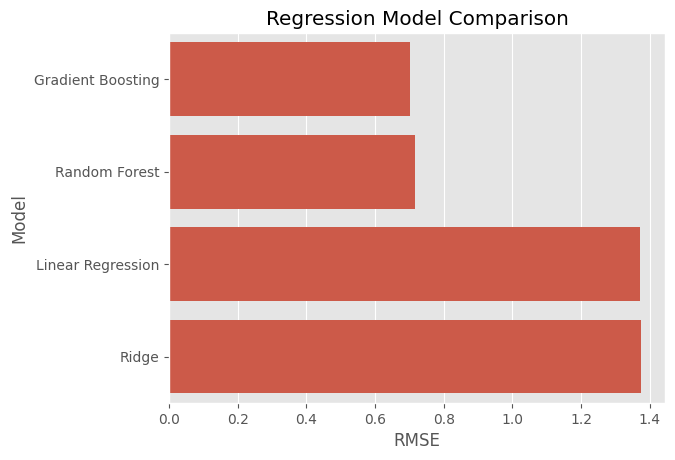

In [27]:
sns.barplot(

    data=results,

    x="RMSE",

    y="Model"

)

plt.title("Regression Model Comparison")

plt.show()

In [28]:
best_model_name = results.iloc[0]["Model"]

print(best_model_name)

Gradient Boosting


In [29]:
best_pipeline = trained_models[best_model_name]

In [30]:
save_model(

    best_pipeline,

    MODEL_DIR / "best_ovulation_model.pkl"

)

print("Model Saved")

Model Saved


In [31]:
from src.config import REPORT_DIR

REPORT_DIR.mkdir(exist_ok=True)

results.to_csv(
    REPORT_DIR / "regression_results.csv",
    index=False
)

print("Regression results saved.")

Regression results saved.


## Conclusions

The regression models were trained and compared using the same preprocessing pipeline.

Feature selection was performed using Mutual Information, reducing the feature space before model training. The best-performing model was saved for future inference.